# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Dataset

## Task #1 :Import the data and describe the sample

### Sort the stock data by date and print the number of stocks

In [34]:
df = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")

In [35]:
print("The number of stocks is ", df.shape[1])

The number of stocks is  9


### Check if data contains any null values

In [36]:
pd.isna(df)

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,False,False,False,False,False,False,False,False,False
2012-01-13,False,False,False,False,False,False,False,False,False
2012-01-17,False,False,False,False,False,False,False,False,False
2012-01-18,False,False,False,False,False,False,False,False,False
2012-01-19,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2020-08-05,False,False,False,False,False,False,False,False,False
2020-08-06,False,False,False,False,False,False,False,False,False
2020-08-07,False,False,False,False,False,False,False,False,False


In [37]:
percent_missing = df.isnull().sum() * 100 / len(df)

missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})

In [38]:
missing_value_df

,column_name,percent_missing
AAPL,AAPL,0.0
BA,BA,0.0
T,T,0.0
MGM,MGM,0.0
AMZN,AMZN,0.0
IBM,IBM,0.0
TSLA,TSLA,0.0
GOOG,GOOG,0.0
sp500,sp500,0.0


There are **no missing values** for any of the columns in the dataset across the whole period.

### What is the average market value of the S&P500?

In [39]:
df.describe()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
count,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,140.819823,189.942700,35.162899,23.105743,915.665665,161.853001,259.600815,783.712512,2218.749554
std,70.827601,103.678586,3.207490,6.963847,697.838905,25.561938,210.988003,334.448057,537.321727
min,55.790001,67.239998,26.770000,7.140000,175.929993,94.769997,22.790001,278.481171,1278.040039
25%,89.165714,124.015000,33.040001,18.545000,316.490005,142.769997,184.595001,527.214416,1847.984985
50%,116.599998,142.419998,34.930000,23.780001,676.010010,156.949997,231.960007,737.599976,2106.629883
75%,175.019997,297.044998,37.419998,28.430000,1593.645019,185.974998,307.350006,1079.744995,2705.810059
max,455.609985,440.619995,43.470001,38.029999,3225.000000,215.800003,1643.000000,1568.489990,3386.149902


In [40]:
print("The average of sp500 is: ", df['sp500'].mean())

The average of sp500 is:  2218.7495540592868


### Which stock or index has the minimum dispersion in dollar value?

In [41]:
df_numeric = df.copy()

# Dispersion measures
dispersion_df = pd.DataFrame({
    "Variance": df_numeric.var(),
    "Standard Deviation": df_numeric.std(),
    "Range": df_numeric.max() - df_numeric.min(),
    "IQR": df_numeric.quantile(0.75) - df_numeric.quantile(0.25)
})

print(dispersion_df)

            Variance  Standard Deviation        Range          IQR
AAPL     5016.549110           70.827601   399.819984    85.854283
BA      10749.249190          103.678586   373.379997   173.029998
T          10.287991            3.207490    16.700001     4.379997
MGM        48.495166            6.963847    30.889999     9.885000
AMZN   486979.137239          697.838905  3049.070007  1277.155014
IBM       653.412664           25.561938   121.030006    43.205002
TSLA    44515.937383          210.988003  1620.209999   122.755005
GOOG   111855.502794          334.448057  1290.008819   552.530579
sp500  288714.638185          537.321727  2108.109863   857.825074


In [42]:
min_disp_col = dispersion_df["Standard Deviation"].idxmin()
print(f"\nColumn with the minimum dispersion: {min_disp_col}")


Column with the minimum dispersion: T


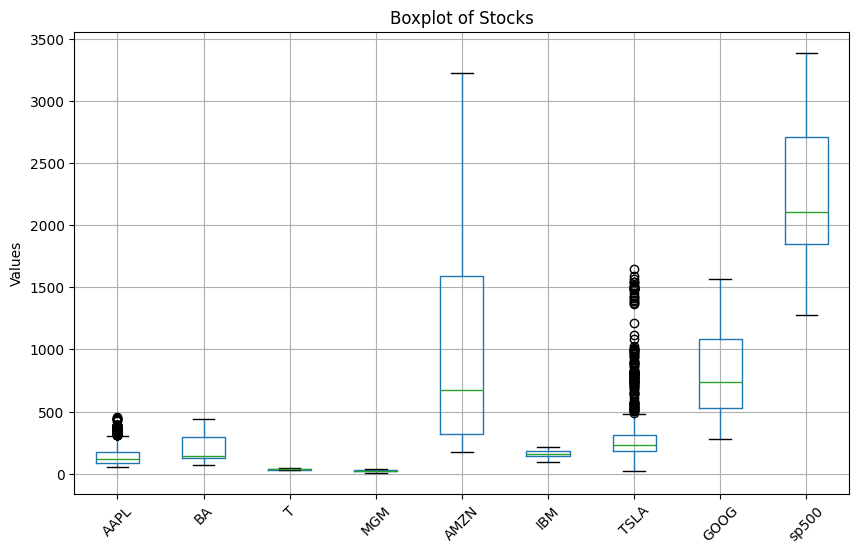

In [43]:
plt.figure(figsize=(10, 6))
df_numeric.boxplot()
plt.title("Boxplot of Stocks")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

As indicated in the boxplot above, it is visible that T stock has got minimum dispersion.

### What is the maximum price for Amazon stock over the specified time period?

In [44]:
max_idx = df['AMZN'].idxmax()         
max_val = df['AMZN'].max()            

print("The maximum value of Amazon is", max_val, "on", max_idx.date())


The maximum value of Amazon is 3225.0 on 2020-08-06


## Task #2 : Plot the data

### Define a function to plot the entire dataframe
– The function takes in a dataframe as an input argument and does not return
anything back

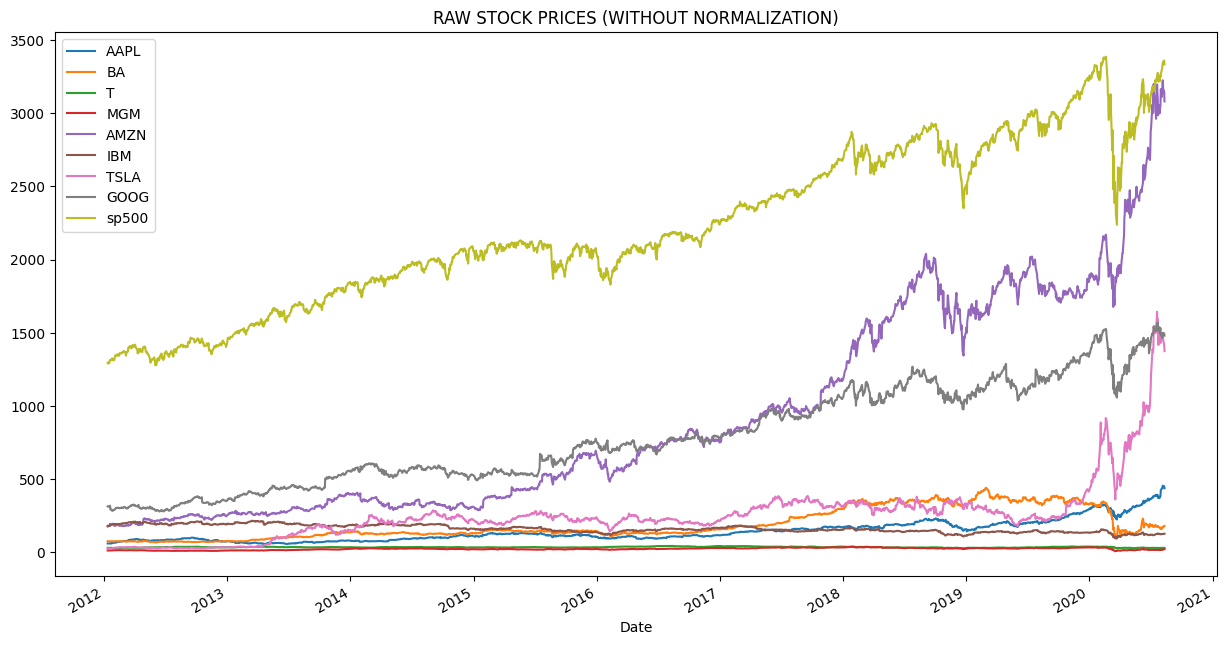

In [45]:
def plot(df):
    df_copy = df.copy()
    df_copy.plot(figsize=(15,8), title = 'RAW STOCK PRICES (WITHOUT NORMALIZATION)')

plot(df)

## Task #3 : Print out normalized (scaled) stock prices

### Define a function to normalize the prices based on the initial price
– The function simply divides every stock by it’s price at the start date (i.e. : Date
= 2012-01-12)

In [46]:
def normalize_prices(df):
    df_norm = df.copy()
    start_row = df_norm.iloc[0]

    df_norm = df_norm / start_row   # Date stays as index
    return df_norm

In [47]:
df

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.130000,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.350000,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.250000,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.730000,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.800000,194.449997,180.520004,26.760000,318.590851,1314.500000
...,...,...,...,...,...,...,...,...,...
2020-08-05,440.250000,174.279999,29.850000,16.719999,3205.030029,125.449997,1485.020020,1473.609985,3327.770020
2020-08-06,455.609985,172.199997,29.840000,18.459999,3225.000000,126.120003,1489.579956,1500.099976,3349.159912
2020-08-07,444.450012,170.020004,30.020000,19.030001,3167.459961,124.959999,1452.709961,1494.489990,3351.280029


### Plot normalized data


In [48]:
normalized_df = normalize_prices(df)

### Optional : Define a function to perform an interactive data plotting using plotly express

## Task #5 : Calculate stock returns

### Define a function to calculate stocks daily returns (for all stocks)
– Loop through each stock

– Loop through each row belonging to the stock

In [49]:
def daily_stock_returns(df):
    returns_df = pd.DataFrame(index=df.index) 
    
    # Loop through each stock column
    for col in df.columns:
        returns = []
        for i in range(len(df)):
            if i == 0:
                returns.append(0)  # No return on the first day
            else:
                prev_price = df[col].iloc[i-1]
                curr_price = df[col].iloc[i]
                daily_return = (curr_price - prev_price) / prev_price
                returns.append(daily_return)
        returns_df[col] = returns
    
    return returns_df

### Plot it!

<Axes: xlabel='Date'>

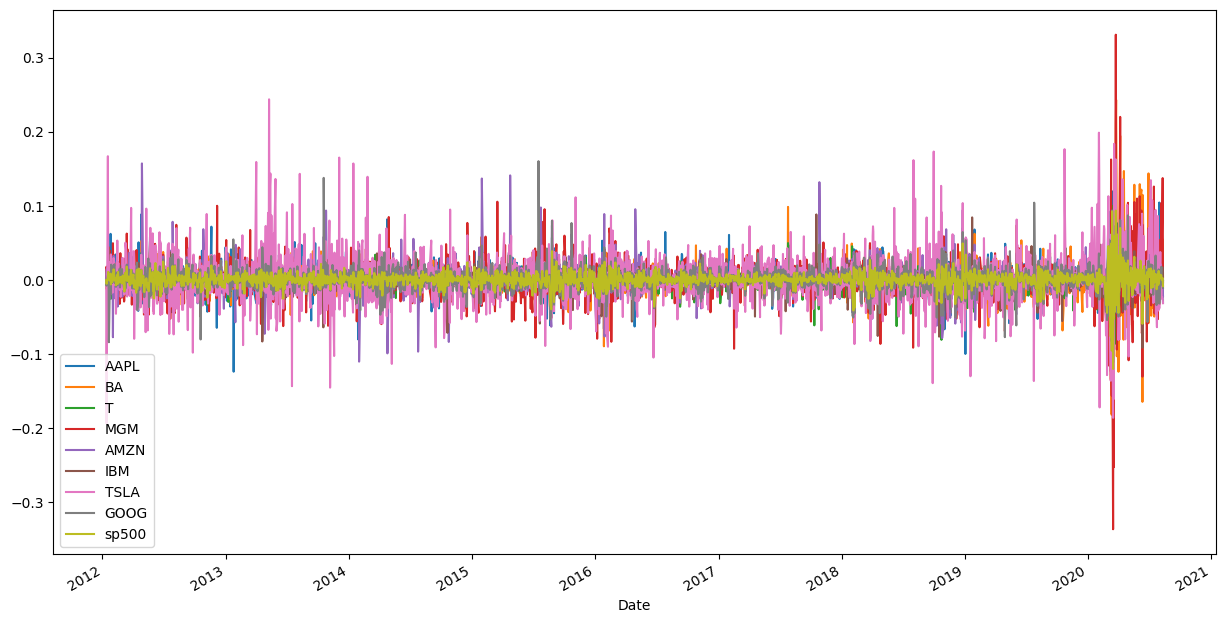

In [50]:
returns_df = daily_stock_returns(df)
returns_df.plot(figsize=(15,8))

### Calculate the correlations between daily returns

In [51]:
correlation_matrix = returns_df.corr()
correlation_matrix

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


### Plot the correlation table as in heat-map

In [52]:
correlation_matrix.style.background_gradient(cmap="coolwarm")

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385250,0.341373,0.384089,0.410234,0.434534,0.288535,0.509125,0.657321
BA,0.385250,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384089,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439142,0.631449
AMZN,0.410234,0.267466,0.233145,0.309016,1.000000,0.339589,0.310084,0.575284,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245609,0.458816,0.703935
TSLA,0.288535,0.250946,0.152515,0.311879,0.310084,0.245609,1.000000,0.322805,0.387921
GOOG,0.509125,0.388048,0.353695,0.439142,0.575284,0.458816,0.322805,1.000000,0.684572
sp500,0.657321,0.641826,0.617463,0.631449,0.539560,0.703935,0.387921,0.684572,1.000000


### What are the top 2 stocks that are positively correlated with the S&P500?

In [53]:
sp_corr = correlation_matrix["sp500"].drop("sp500")
sp_corr

AAPL    0.657321
BA      0.641826
T       0.617463
MGM     0.631449
AMZN    0.539560
IBM     0.703935
TSLA    0.387921
GOOG    0.684572
Name: sp500, dtype: float64

In [54]:
print("The two stocks most correlated with S&P500 are:")
sp_corr.sort_values(ascending=False).head(2)

The two stocks most correlated with S&P500 are:


IBM     0.703935
GOOG    0.684572
Name: sp500, dtype: float64

### What is the correlation between Amazon and Boeing? Comment on your answer

In [55]:
print("The correlation between AMZN and BA is:", correlation_matrix.loc["AMZN", "BA"])

The correlation between AMZN and BA is: 0.2674661380836475


### What is the correlation between MGM and Boeing? Comment on your answer

In [56]:
print("The correlation between AMZN and BA is:", correlation_matrix.loc["MGM", "BA"])

The correlation between AMZN and BA is: 0.5542294514206464


### Plot the histograms of daily returns and comment

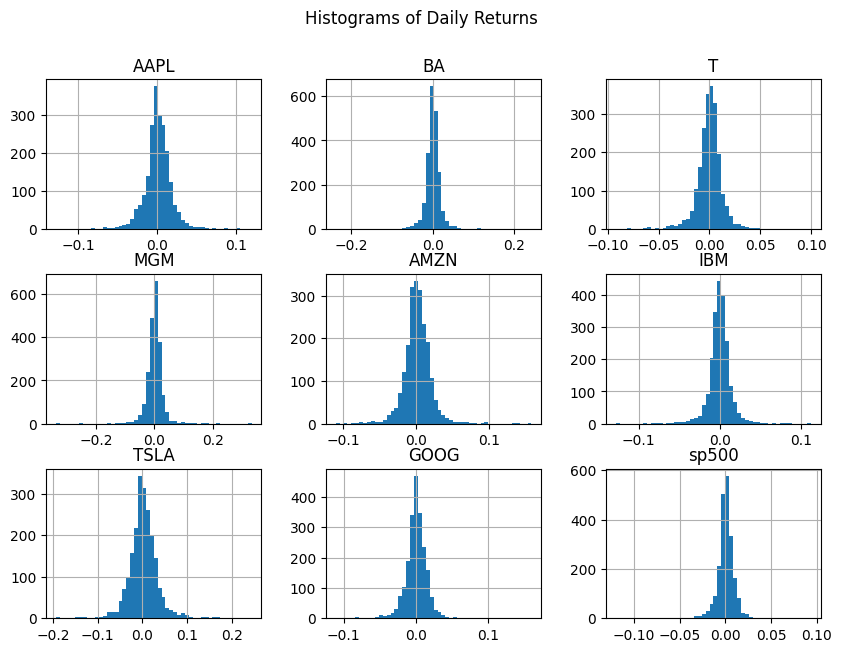

In [57]:
returns_df.hist(bins=50, figsize=(10,7))
plt.suptitle("Histograms of Daily Returns")
plt.show()

### Optional : Define a function to perform an interactive and fancy histograms plots using Plotly module (figure factory module)

## Task #6 : Portfolio weights

### Write a function that will :
– Simulate 1000 portfolios with random weights

– Compute the return, the variance and the Sharpe ratio of each portfolio

– Return the maximum Sharpe ratio and its weights

In [58]:
def simulate_portfolios(returns_df, num_portfolios=1000):
    # Drop Date column if present
    r = returns_df.drop(columns=['Date'], errors='ignore')
    
    # Mean and covariance of annualized returns 
    mean_returns = r.mean() * 252
    cov_matrix = r.cov() * 252

    
    results = []
    
    for _ in range(num_portfolios):
        # Random weights that sum to 1
        weights = np.random.random(len(r.columns))
        weights /= np.sum(weights)
        
        # Portfolio return and variance
        port_return = np.dot(weights, mean_returns)
        port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
        port_vol = np.sqrt(port_var)
        
        # Sharpe ratio (risk-free = 0)
        sharpe = port_return / port_vol if port_vol != 0 else 0
        
        results.append((port_return, port_var, sharpe, weights))
    
    # Find portfolio with max Sharpe
    best = max(results, key=lambda x: x[2])
    
    best_return, best_var, best_sharpe, best_weights = best
    return best_sharpe, best_weights


In [59]:
best_sharpe, best_weights = simulate_portfolios(returns_df)

print("Max Sharpe ratio:", best_sharpe)

Max Sharpe ratio: 1.3244127205540068


### What are the weights of your tangency portfolio? 


In [60]:
print("Weights:", best_weights)

Weights: [0.25341362 0.06930892 0.06014256 0.00275361 0.19359471 0.05055092
 0.19994016 0.01956544 0.15073007]


### What would have been the performance of this portfolio over the sample period? Plot it!

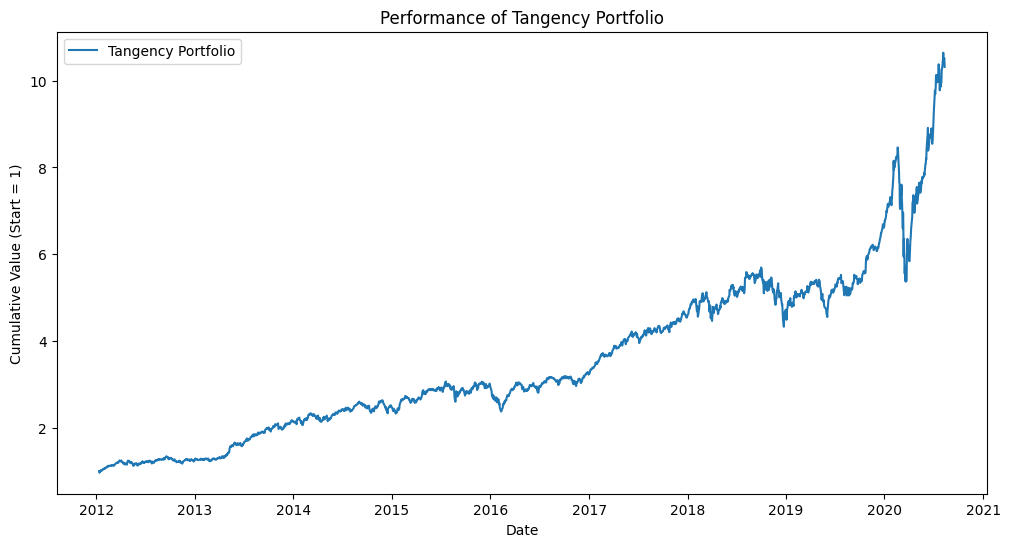

In [61]:
# Make a copy so we can keep Date as index
r = returns_df.copy()

# Daily portfolio returns
portfolio_returns = (r * best_weights).sum(axis=1)

# Cumulative performance
cumulative = (1 + portfolio_returns).cumprod()

# Plot
plt.figure(figsize=(12,6))
plt.plot(cumulative, label="Tangency Portfolio")
plt.title("Performance of Tangency Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Value (Start = 1)")
plt.legend()
plt.show()


Showing Luca git

### Optional : Define a function that finds the weights that minimize the variance for all possible level or return (i.e., that draw the efficient frontier). Plot it against the previous scatter plot

## Task #7 : Testing Portfolio Theory - Optional

### Re-run Task #6 but only on the first part of the sample (2012-2016)

### Find out what are the optimal weights for this period

### Simulate your optimal portfolio on the second part of the sample (2016-end)
– How does it perform?
– Plot the expected (measured over the 1st period) vs. the realized return and volatility (over the second).

### Super optional : Let’s go a step further. Every year, you re-balance your portfolio based on last year data. What is your performance overall?